In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import TargetEncoder, LabelEncoder
from datetime import datetime
from geopy.distance import geodesic
from sklearn.cluster import KMeans

In [3]:
# displays all columns 
pd.set_option('display.max_columns', None)

In [4]:
def calculate_age(dob):
    today = datetime.today()
    return today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day))

In [5]:
def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
    km = 6371 * c
    return km

In [6]:
def categorize_location(city_pop):
    if city_pop > 50000:
        return 1
    elif city_pop > 10000:
        return 2
    else:
        return 3

In [7]:
# Function to compute distance between merchant and transaction locations
def calculate_distance_between_locations(lat1, long1, lat2, long2):
    return geodesic((lat1, long1), (lat2, long2)).kilometers


In [8]:
from category_encoders.cat_boost import CatBoostEncoder
def catBoostEncodingFunc(df):
    cbe_encoder = CatBoostEncoder()
    categorical_col = ['merchant', 'street', 'city', 'state']
    train_cbe = cbe_encoder.fit_transform(df[categorical_col], df['is_fraud'])
    train_cbe.columns = ['cbe_' + col for col in categorical_col]
    df_cbe = pd.concat([df, train_cbe], axis=1)
    return df_cbe

In [9]:
def oneHotEncodingFunc(df):
    from sklearn.preprocessing import OneHotEncoder
    encoder = OneHotEncoder(drop='first')
    # Columns to one-hot encode
    columns_to_encode = ['category', 'age_group', 'job_category']

    # Apply one-hot encoding to the categorical columns
    one_hot_encoded = encoder.fit_transform(df[columns_to_encode])
    feature_names = encoder.get_feature_names_out()
    one_hot_encoded_df = pd.DataFrame.sparse.from_spmatrix(one_hot_encoded)
    one_hot_encoded_df.columns = feature_names
    df_combined = pd.concat([one_hot_encoded_df, df], axis=1)
    return df_combined

In [10]:
job_categories = {
    "Psychology & Therapy": [
        'Psychologist, counselling', 'Dance movement psychotherapist',
        'Therapist, occupational', 'Forensic psychologist', 'Counsellor',
        'Child psychotherapist', 'Psychologist, forensic', 'Psychotherapist, child',
        'Psychologist, sport and exercise', 'Occupational psychologist',
        'Therapist, horticultural', 'Art therapist', 'Music therapist',
        'Therapist, drama', 'Sport and exercise psychologist',
        'Clinical psychologist', 'Counselling psychologist', 'Psychotherapist',
        'Psychologist, clinical', 'Therapist, music', 'Psychiatrist','Psychology & Therapy',
        
    ],
    "Education & Training": [
        'Special educational needs teacher', 'IT trainer', 'Teacher, English as a foreign language',
        'Teacher, secondary school', 'Teacher, early years/pre', 'English as a second language teacher',
        'Teacher, primary school', 'Teacher, adult education', 'Lecturer, higher education',
        'Lecturer, further education', 'Education administrator', 'Teaching laboratory technician',
        'Further education lecturer', 'Educational psychologist', 'Professor Emeritus',
        'Associate Professor', 'Higher education careers adviser', 'Private music teacher',
        'Education & Training','Primary school teacher', 'Secondary school teacher', 'Early years teacher', 
        'Teacher, special educational needs', 'Learning mentor', 'Education officer, museum', 'Museum education officer', 
        'English as a foreign language teacher', 'TEFL teacher', 'Careers adviser', 'Careers information officer', 
        'Development worker, community', 'Education officer, community', 'Armed forces training and education officer',
        'Music tutor', 
        'Training and development officer', 
        'Learning disability nurse', 'Librarian, academic', 'Librarian, public','Academic librarian', 'Public librarian'
    
    ],
    "Engineering & Technology": [
        'Engineer, land', 'Systems developer', 'Engineer, mining', 'Electrical engineer','Engineer',
        'Engineer, electronics', 'Engineer, broadcasting (operations)',
        'Engineer, biomedical', 'Engineering geologist', 'Engineer, manufacturing',
        'Engineer, technical sales', 'Engineer, structural', 'Engineer, control and instrumentation',
        'Mechanical engineer', 'Civil engineer, contracting', 'Engineer, petroleum',
        'Engineer, drilling', 'Engineer, aeronautical', 'Engineer, agricultural',
        'Engineer, civil (consulting)', 'Engineer, site', 'Engineer, civil (contracting)',
        'Engineer, materials', 'Biomedical engineer', 'Maintenance engineer',
        'Engineer, communications', 'Engineer, building services', 'Engineer, structural',
        'Engineer, control and instrumentation', 'Engineer, automotive', 'Engineer, production',
        'Engineer, technical sales','Engineering & Technology', 'Civil engineer', 'Mechanical engineer', 
        'Chemical engineer', 'Electrical engineer', 'Electronics engineer', 'Aerospace engineer', 
        'Aeronautical engineer', 'Structural engineer', 'Materials engineer', 'Mining engineer', 
        'Surveyor, land/geomatics', 'Surveyor, minerals', 'Surveyor, hydrographic', 'Surveyor, rural practice', 
        'Surveyor, building', 'Surveyor, commercial/residential', 'Surveyor, construction', 'Surveyor, quantity', 
        'Surveyor, town planner', 'Surveyor, property', 'Building control surveyor', 'Building services engineer', 
        'Construction engineer', 'Contracts engineer', 'Electrical engineer', 'Electronics engineer', 'Energy engineer', 'Environmental engineer', 
        'Manufacturing engineer', 'Mining engineer', 'Structural engineer', 'Technical brewer', 'Water engineer',
        'Land/geomatics surveyor', 
        'Wellsite geologist', 
        'Minerals surveyor',
        'Control and instrumentation engineer', 
        'Production engineer', 
        'Engineer, maintenance', 
        'Manufacturing systems engineer', 
        'Petroleum engineer', 
        'Contracting civil engineer', 'Surveyor, mining', 
        'Commercial/residential surveyor', 
        'Rural practice surveyor', 
        'Planning and development surveyor', 'Building surveyor', 'Site engineer','Quantity surveyor','Town planner'
    
    ],
    "Healthcare & Medicine": [
        'Radiographer, diagnostic', 'Physiotherapist', 'Paediatric nurse',
        'Clinical biochemist', 'Clinical research associate', 'Health visitor',
        'Nutritional therapist', 'Dietitian', 'Occupational therapist',
        'Physician', 'Podiatrist', 'Health promotion specialist',
        'Immunologist', 'Neurosurgeon', 'Pharmacist, hospital',
        'Psychiatric nurse', 'Community pharmacist', 'Medical physicist',
        'Paediatric nurse', 'Hospital doctor', 'Diagnostic radiographer',
        'Doctor, hospital', 'Medical technical officer', 'General practice doctor',
        'Hospital pharmacist', 'Pharmacologist', 'Surgeon', 'Therapist, sports',
        'Physician', 'Health service manager', 'Medical secretary',
        'Biochemist, clinical', 'Doctor, general practice', 'Osteopath',
        'Therapist, art', 'Chiropodist', 'Scientist, physiological', 'Healthcare & Medicine', 'Doctor', 'Physician', 'Surgeon', 'Nurse, mental health', 
        "Nurse, children's", 'Paramedic', 'Ambulance person', 'Optician, dispensing', 
        'Optometrist', 'Pharmacist, community', 'Medical sales representative', 'Audiological scientist', 
        'Physiological scientist', 'Psychiatrist', 'Veterinary surgeon', 'Radiographer, therapeutic', 'Health physicist', 
        'Exercise physiologist', 'Scientist, biomedical', 'Scientist, marine', 'Biomedical scientist', 'Embryologist, clinical', 'Homeopath', 'Acupuncturist', 
        'Herbalist', 'Occupational hygienist', 'Dispensing optician', 'Mental health nurse', 
        'Orthoptist', 'Oncologist', 'Animal nutritionist', 'Phytotherapist', 'Pathologist'
    
    ],
    "Science & Research": [
        'Scientist, research (maths)', 'Research scientist (life sciences)',
        'Research scientist (physical sciences)', 'Research scientist (medical)',
        'Biomedical scientist', 'Research officer, trade union',
        'Geochemist', 'Geoscientist', 'Cytogeneticist', 'Clinical cytogeneticist',
        'Research officer, political party', 'Research officer, trade union',
        'Scientist, clinical (histocompatibility and immunogenetics)',
        'Scientist, research (medical)', 'Scientist, research (physical sciences)',
        'Research officer, political party', 'Clinical research associate',
        'Field seismologist', 'Geologist, engineering', 'Research scientist (maths)',
        'Geophysicist/field seismologist', 'Science & Research', 'Research scientist', 'Clinical scientist', 
        'Data scientist', 'Geoscientist', 'Physicist, medical', 'Biotechnologist', 'Microbiologist', 'Marine scientist', 'Biomedical scientist', 
        'Embryologist, clinical', 'Hydrologist', 'Environmental scientist', 'Plant scientist', 'Materials scientist', 
        'Toxicologist', 'Analytical chemist', 'Biostatistician', 'Biotechnologist', 'Oceanographer', 'Agricultural consultant', 'Marine scientist', 
        'Biomedical scientist', 'Embryologist, clinical', 'Microbiologist', 'Scientist, audiological', 
        'Animal technologist', 
        'Geneticist, molecular', 
        'Plant breeder/geneticist', 
        'Herpetologist', 
        'Field trials officer'
    
    ],
    "Finance & Legal": [
        'Patent attorney', 'Corporate investment banker', 'Claims inspector/assessor',
        'Insurance broker', 'Accountant, chartered public finance', 'Accountant, chartered',
        'Accountant, chartered certified', 'Accountant, chartered public finance',
        'Solicitor', 'Chartered accountant', 'Solicitor, Scotland',
        'Tax inspector', 'Investment analyst', 'Chartered legal executive (England and Wales)',
        'Financial trader', 'Chief Financial Officer', 'Chief Executive Officer',
        'Chief Operating Officer', 'Chief Strategy Officer', 'Chief Technology Officer',
        'Chief Marketing Officer', 'Chief of Staff', 'Investment banker, corporate',
        'Investment banker, operational', 'Financial adviser', 'Tax adviser',
        'Legal secretary', 'Trade mark attorney', 'Pensions consultant', 
        'Tax inspector', 'Insurance underwriter', 'Insurance claims handler', 'Finance & Legal', 'Senior tax professional/tax inspector', 'Economist', 'Pension scheme manager', 'Chartered loss adjuster', 'Loss adjuster, chartered', 'Risk analyst', 
        'Chartered public finance accountant', 'Insurance risk surveyor', 'Licensed conveyancer', 'Barrister\'s clerk', 'Comptroller', 'Tax inspector', 
        'Chartered loss adjuster',
        'Futures trader', 
        'Equities trader', 'Operational investment banker'
    
    ],
    "Creative Arts & Design": [
        'Designer, multimedia', 'Designer, furniture', 'Designer, jewellery',
        'Designer, television/film set', 'Designer, textile',
        'Fine artist', 'Graphic designer', 'Illustrator', 'Ceramics designer',
        'Designer, ceramics/pottery', 'Special effects artist', 'Artist',
        'Designer, interior/spatial', 'Designer, exhibition/display', 
        'Textile designer', 'Designer, industrial/product', 
        'Designer, television/film set', 'Designer, ceramics/pottery',
        'Designer, furniture', 'Designer, jewellery', 'Designer, multimedia',
        'Animator', 'Architect', 'Architectural technologist', 'Architect, landscape',
        'Designer, multimedia', 'Interior and spatial designer', 'Designer, ceramics/pottery',
        'Fashion designer', 'Creative Arts & Design', 'Art gallery manager', 'Stage manager', 'Set designer', 'Theatre manager', 'Theatre director', 'Jewellery designer', 'Furniture designer', 
        'Exhibition designer', 'Broadcast presenter', 'Presenter, broadcasting', 'Magazine journalist', 'Advertising copywriter', 'Musician', 'Dancer', 'Glass blower/designer', 'Theme park manager', 
        'Film/video production manager', 'Production assistant, television', 'Production assistant, radio', 'Location manager', 'Magazine features editor', 
        'Curator', 
        'Gaffer', 
        'Colour technologist', 
        'Arts development officer', 
        'Furniture conservator/restorer', 
        'Visual merchandiser', 
        'Landscape architect', 
        'Conservator, furniture', 'Exhibitions officer, museum/gallery', 
        'Museum/gallery exhibitions officer', 
        'Cartographer'
    
    ],
    "Business & Management": [
        'Public affairs consultant', 'Event organiser', 'Call centre manager',
        'Leisure centre manager', 'Retail merchandiser', 'Retail manager',
        'Store manager', 'Store planner', 'Project manager',
        'Production manager', 'Operations manager', 'Retail buyer', 
        'Retail banker', 'Hotel manager', 'Restaurant manager, fast food',
        'Store planner', 'Operations manager', 'Merchandiser, retail',
        'Logistics and distribution manager', 'Management consultant', 
        'Retail manager', 'Store manager', 'Facilities manager', 'Programme researcher',
        'Chief Marketing Officer', 'Chief Strategy Officer', 'Chief Financial Officer',
        'Chief Operating Officer', 'Chief Executive Officer', 'Chief of Staff',
        'Purchasing manager', 'Business & Management', 'Company secretary', 'Operations geologist', 'Product/process development scientist', 'Product designer', 'Product manager', 'Sales promotion account executive', 'Sales executive', 'Sales professional, IT', 
        'Human resources officer', 'Personnel officer', 'Senior tax professional/tax inspector', 'Accountant', 'Accounting technician', 'Risk analyst', 'Pension scheme manager', 'Management consultant', 'Operations manager', 'Procurement manager', 
        'Chartered loss adjuster', 'Loss adjuster, chartered', 'Industrial buyer', 'Buyer, industrial', 'Buyer, retail', 'Sales professional, IT', 'Sales promotion account executive', 'Chartered public finance accountant', 'Comptroller', 'Project manager', 'Administrator', 'Administrator, education', 'Administrator, local government', 
        'Administrator, charities/voluntary organisations', 'Administrator, arts', 'Estate manager/land agent', 'Public house manager', 'Catering manager', 
        'Operations geologist',
        'Business & Management', 
        'Secretary/administrator', 
        'Farm manager', 
        'Fitness centre manager', 
        'Sports administrator', 
        'Operations manager', 
        'Marketing executive', 
        'Records manager', 'Arts development officer', 'Secretary/administrator', 'Outdoor activities/education manager', 'Quarry manager'
    
    ],
    "Communications & Media": [
        'Journalist, newspaper', 'Journalist, broadcast', 'Editor, film/video',
        'Editor, magazine features', 'Copywriter, advertising', 'Editor, commissioning',
        'Editor, magazine features', 'Copywriter, advertising', 'Commissioning editor',
        'Producer, television/film/video', 'Producer, radio', 'Television camera operator',
        'Camera operator', 'Television floor manager', 'Press photographer',
        'Television production assistant', 'Video editor', 'Media buyer',
        'Media planner', 'Radio broadcast assistant', 'Press sub', 'Film/video editor',
        'Television/film/video producer', 'Television floor manager', 'Broadcast journalist',
        'Broadcast engineer', 'Television camera operator', 'Camera operator',
        'Television production assistant', 'Radio producer', 'Radio broadcast assistant',
        'Television/film/video producer', 'Communications & Media', 'Broadcast presenter', 'Television production assistant', 'Radio production assistant', 'Magazine journalist', 'Copywriter', 'Advertising copywriter', 'Public relations officer', 'Public relations account executive', 'Market researcher', 'Magazine features editor', 'Magazine journalist', 'Production assistant, television', 'Production assistant, radio', 
        'Magazine features editor', 'Programme researcher, broadcasting/film/video', 
        'Copy', 
        'Advertising account executive', 
        'Advertising account planner', 'Writer'
    
    ],
    "IT & Technology": [
        'Systems developer', 'Systems analyst', 'Network engineer', 'Applications developer',
        'Telecommunications researcher', 'Database administrator', 'IT consultant',
        'IT trainer', 'Information systems manager', 'Programmer, multimedia',
        'Multimedia programmer', 'Web designer', 'IT consultant', 'Systems developer',
        'Network engineer', 'Programmer, multimedia', 'Programmer, applications',
        'Database administrator', 'Web designer', 'IT consultant', 'Network engineer',
        'Information systems manager', 'IT trainer', 'Systems analyst', 'IT & Technology', 'IT consultant', 'IT manager', 'Software developer', 'Software engineer', 'Web developer', 'Web designer', 'Network engineer', 'Systems analyst', 'Data scientist', 'Cybersecurity analyst', 'Technical support engineer', 'Information officer', 'Digital marketer', 'SEO specialist', 'Content manager', 
        'Cloud computing engineer', 'IT & Technology', 
        'Communications engineer'
    
    ],
    "Environmental & Conservation": [
        'Nature conservation officer', 'Arboriculturist', 'Amenity horticulturist',
        'Conservation officer, historic buildings', 'Environmental consultant',
        'Environmental education officer', 'Ecologist', 'Environmental health practitioner',
        'Environmental manager', 'Environmental consultant', 'Environmental education officer',
        'Horticulturist, commercial', 'Horticultural therapist', 'Conservator, museum/gallery',
        'Museum/gallery conservator', 'Horticulturist, commercial', 'Horticultural consultant',
        'Tree surgeon', 'Race relations officer', 'Conservation officer, historic buildings',
        'Historic buildings inspector/conservation officer', 'Horticulturist, commercial',
        'Horticultural consultant', 'Tree surgeon', 'Nature conservation officer',
        'Arboriculturist', 'Amenity horticulturist', 'Environmental & Conservation', 'Warden/ranger', 'Fisheries officer', 'Forest/woodland manager', 'Soil scientist', 'Hydrologist', 'Hydrographic surveyor', 'Water quality scientist', 'Energy engineer', 
        'Energy manager',
        'Waste management officer', 
        'Heritage manager', 
    
    ],
    "Law & Security": [
        'Police officer', 'Probation officer', 'Immigration officer',
        'Solicitor', 'Barrister', 'Claims inspector/assessor', 'Contractor',
        'Lawyer', 'Solicitor, Scotland', 'Barrister', 'Legal secretary', 
        'Insurance claims handler', 'Police officer', 'Probation officer', 
        'Immigration officer', 'Claims inspector/assessor', 'Insurance broker',
        'Insurance underwriter', 'Lawyer', 'Legal secretary', 'Prison officer', 
        'Claims inspector/assessor', 'Lawyer', 'Legal secretary', 
        'Immigration officer', 'Law & Security', 'Legal officer', 'Security officer', 'Police officer', 'Firefighter', 'Barrister', 'Solicitor', 'Legal executive', 'Chartered loss adjuster', 'Loss adjuster, chartered', 'Trading standards officer', 'Tax inspector', 'Insurance risk surveyor', 'Risk analyst', 
        'Legal officer'
    
    ],
    "Science & Technology": [
        'Science writer', 'Research scientist (physical sciences)', 
        'Research scientist (life sciences)', 'Research scientist (medical)',
        'Science writer', 'Hydrogeologist', 'Physiologist', 'Marine scientist',
        'Science writer', 'Physiologist', 'Hydrogeologist', 'Clinical cytogeneticist',
        'Research scientist (medical)', 'Research scientist (physical sciences)', 
        'Research scientist (life sciences)', 'Research scientist (maths)',
        'Research scientist (physical sciences)', 'Research scientist (maths)',
        'Clinical cytogeneticist', 'Research scientist (physical sciences)',
        'Science writer', 'Hydrogeologist', 'Physiologist', 'Marine scientist',
        'Research scientist (medical)', 'Research scientist (maths)',
        'Research scientist (life sciences)', 'Science & Technology', 'Industrial/product designer', 'Metallurgist', 'Physicist, medical', 'Clinical scientist', 'Research scientist', 'Geoscientist', 'Marine scientist', 'Biomedical scientist', 'Audiological scientist', 'Scientist, marine', 'Biomedical scientist', 'Embryologist, clinical', 'Microbiologist', 'Hydrologist', 'Data scientist', 'Information officer', 'Research scientist', 'Industrial/product designer', 'Microbiologist', 'Clinical scientist', 'Biotechnologist', 
        'Operations geologist', 'Scientific laboratory technician', 
        'Statistician', 
        'Chemist, analytical', 
        'Operational researcher'
    
    ],
    "Public Service & Government": [
        'Police officer', 'Civil Service administrator', 'Civil Service fast streamer',
        'Local government officer', 'Housing officer', 'Environmental health practitioner',
        'Firefighter', 'Civil Service fast streamer', 'Probation officer',
        'Social research officer, government', 'Social research officer, government',
        'Housing manager/officer', 'Civil Service administrator', 'Local government officer',
        'Civil Service fast streamer', 'Housing officer', 'Environmental health practitioner',
        'Civil Service administrator', 'Local government officer', 'Public Service & Government', 'Armed forces training and education officer', 'Armed forces logistics/support/administrative officer', 'Trading standards officer', 'Public relations officer', 'Public relations account executive', 'Risk analyst', 'Regulatory affairs officer', 'Health and safety adviser', 'Regulatory affairs officer', 'Equality and diversity officer', 'Volunteer coordinator', 'Charity officer', 'Charity fundraiser', 'Aid worker', 
        'Emergency planning/management officer', 'Armed forces technical officer', "Politician's assistant", 
        'Intelligence analyst', 
        'Advice worker'
    
    ],
    "Transport & Logistics": [
        'Transport planner', 'Logistics and distribution manager', 'Air traffic controller',
        'Freight forwarder', 'Warehouse manager', 'Freight forwarder', 
        'Freight forwarder', 'Freight forwarder', 'Freight forwarder',
        'Transport planner', 'Logistics and distribution manager', 'Warehouse manager',
        'Warehouse manager', 'Transport manager', 'Logistics and distribution manager',
        'Logistics and distribution manager', 'Warehouse manager', 'Transport manager',
        'Freight forwarder', 'Freight forwarder', 'Freight forwarder',
        'Transport manager', 'Logistics and distribution manager', 'Warehouse manager',
        'Warehouse manager', 'Warehouse manager', 'Warehouse manager', 
        'Transport manager', 'Transport manager', 'Freight forwarder', 
        'Transport manager', 'Transport & Logistics', 'Pilot, airline', 'Airline pilot', 'Operations geologist', 'Drilling engineer', 'Mudlogger', 'Logistics officer', 'Logistics/support/administrative officer', 'Ship broker', 'Cabin crew', 'Air cabin crew', 'Air broker', 'Marine scientist', 'Naval architect', 'Geologist, wellsite', 
        'Seismic interpreter'
    
    ],
    "Social Services & Community Work": [
        'Community education officer', 'Community arts worker', 'Community education officer',
        'Community development worker', 'Community education officer', 
        'Community arts worker', 'Community pharmacist', 'Social worker',
        'Community development worker', 'Community development worker',
        'Community pharmacist', 'Youth worker', 'Community arts worker',
        'Community pharmacist', 'Social worker', 'Youth worker', 
        'Community development worker', 'Community arts worker', 'Community pharmacist',
        'Community pharmacist', 'Community development worker', 'Social worker', 
        'Social worker', 'Youth worker', 'Youth worker', 'Youth worker',
        'Social worker', 'Social Services & Community Work', 'Social worker', 'Counsellor', 'Charity officer', 'Charity fundraiser', 'Development worker, community', 'Volunteer coordinator', 'Careers adviser', 'Careers information officer', 'Community worker', 'Youth worker', 'Housing officer', 'Community development officer', 'Equal opportunities officer', 'Community education officer', 'Social researcher', 
        'Development worker, international aid'
    
    ],
    "Hospitality & Tourism": [
        'Travel agency manager', 'Tourism officer', 'Hotel manager',
        'Tourist information centre manager', 'Restaurant manager, fast food',
        'Tourist information centre manager', 'Hotel manager', 'Tour manager',
        'Hotel manager', 'Tour manager', 'Travel agency manager', 
        'Travel agency manager', 'Restaurant manager, fast food',
        'Hotel manager', 'Tour manager', 'Tourism officer', 
        'Restaurant manager, fast food', 'Travel agency manager', 
        'Travel agency manager', 'Restaurant manager, fast food', 'Restaurant manager, fast food', 'Hospitality & Tourism', 'Hotel manager', 'Catering manager', 'Public house manager', 'Tour guide', 'Travel agent', 'Tour operator', 'Barista', 'Hotel receptionist', 
        'Tourism officer'
    
    ],
    "Retail & Customer Service": [
        'Retail merchandiser', 'Retail manager', 'Store manager',
        'Store planner', 'Retail merchandiser', 'Retail buyer', 
        'Retail merchandiser', 'Retail buyer', 'Store manager',
        'Store planner', 'Retail buyer', 'Retail manager', 
        'Store manager', 'Retail buyer', 'Retail merchandiser', 
        'Store planner', 'Store manager', 'Retail buyer',
        'Store manager', 'Retail merchandiser', 'Store planner',
        'Store manager', 'Store planner', 'Store manager', 'Retail & Customer Service', 'Retail manager', 'Retail buyer', 'Retail merchandiser', 'Sales assistant', 'Customer service manager', 'Customer service adviser', 'Sales assistant', 'Sales executive', 'Retail buyer', 
        'Retail merchandiser', 'Bookseller'
    
    ],
    "Other/Uncategorized": [
        'Dealer', 
        'Archivist', 
        'Lexicographer', 
        'Commercial horticulturist',          
        'Archaeologist', 
        'Sub', 
        'Make',
        'Garment/textile technologist', 
        'Sports development officer',
        'Clothing/textile technologist', 
        'Interpreter'
    ]
}


In [11]:
def data_processing(df_path):
    df = pd.read_csv(df_path)
    df.drop(df.columns[0], axis=1, inplace=True)
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])
    
    df['year'] = df['trans_date_trans_time'].dt.year
    df['month'] = df['trans_date_trans_time'].dt.month
    df['day'] = df['trans_date_trans_time'].dt.day
    df['time'] = df['trans_date_trans_time'].dt.time
    
    df['time'] = pd.to_datetime(df.time, format='%H:%M:%S')
    
    # Ensure 'dob' is in datetime format
    df['dob'] = pd.to_datetime(df['dob'])

    # Calculate age and create a new 'age' column
    df['age'] = df['dob'].apply(calculate_age)
    
    # Calculate distance and create a new 'distance_km' column
#     df['dist_client_merch'] = df.apply(lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1)
    # Apply the function to create a new feature
    df['distance_to_merchant'] = df.apply(
        lambda row: calculate_distance_between_locations(row['lat'], row['long'], row['merch_lat'], row['merch_long']),
        axis=1
    )
    
    df['location_type'] = df['city_pop'].apply(categorize_location)
    
    # Apply K-Means clustering
    coords = df[['lat', 'long']]
    kmeans = KMeans(n_clusters=5, random_state=0).fit(coords)
    df['location_cluster'] = kmeans.labels_
    
    le = LabelEncoder()
    df['le_gender'] = le.fit_transform(df['gender'])
    
    # Define the bins and the corresponding labels
    bins = [0, 18, 25, 35, 45, 55, 65, 120]
    labels = ['<18 (Minor)', '18-24 (Young Adult)', '25-34 (Early Adulthood)', 
              '35-44 (Mid Adulthood)', '45-54 (Late Adulthood)', 
              '55-64 (Early Senior Adulthood)', '65+ (Senior Citizen)']
    
    
    reverse_dict = {job.lower().strip(): category for category, jobs in job_categories.items() for job in jobs}

    # Define a function to map each job to its category
    def map_job_to_category(job):
        # Convert the job to lowercase and strip whitespace before looking it up
        cleaned_job = job.lower().strip()
        return reverse_dict.get(cleaned_job, 'Other/Uncategorized')  # Return the original job if not found

    # Apply the function to create the 'job_category' column
    df['job_category'] = df['job'].apply(map_job_to_category)

# Add the age group column
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
    df['cc_num_frequency'] = df.groupby('cc_num')['cc_num'].transform('count')
    df['fraud_transaction_count'] = df.groupby('cc_num')['is_fraud'].transform('sum')
    
    df = catBoostEncodingFunc(df)
    df = oneHotEncodingFunc(df)
    
    from sklearn.preprocessing import StandardScaler
    z_score_scaler = StandardScaler()
    df['amt_z_score'] = z_score_scaler.fit_transform(df[['amt']])
    df['city_pop_z_score'] = z_score_scaler.fit_transform(df[['city_pop']])
#     te = TargetEncoder()
#     le_job = le.fit_transform(df['job'])
#     df['le_job'] = le_job
#     le_street = le.fit_transform(df['street'])
#     df['le_street'] = le_street
#     le_merchant = le.fit_transform(df['merchant'])
#     df['le_merchant'] = le_merchant
#     le_city = le.fit_transform(df['city'])
#     df['le_city'] = le_city
#     le_state = le.fit_transform(df['state'])
#     le_category = le.fit_transform(df['category'])
#     df['le_category'] = le_category
    
    return df

In [12]:
df = data_processing('../fraudTrain.csv')

In [13]:
df.select_dtypes(include='object').nunique()

merchant            693
category             14
first               352
last                481
gender                2
street              983
city                894
state                51
job                 494
trans_num       1296675
job_category         19
dtype: int64

In [14]:
(df['job_category'].value_counts())

job_category
Engineering & Technology            176739
Healthcare & Medicine               141186
Business & Management               114222
Creative Arts & Design               99383
Communications & Media               99227
Education & Training                 86790
Environmental & Conservation         65431
Science & Research                   60013
Finance & Legal                      57218
Psychology & Therapy                 57022
Science & Technology                 56434
Public Service & Government          52213
Law & Security                       46220
IT & Technology                      45204
Other/Uncategorized                  43495
Transport & Logistics                38512
Social Services & Community Work     31651
Hospitality & Tourism                14883
Retail & Customer Service            10832
Name: count, dtype: int64

In [15]:
df.sample()

,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,age_group_25-34 (Early Adulthood),age_group_35-44 (Mid Adulthood),age_group_45-54 (Late Adulthood),age_group_55-64 (Early Senior Adulthood),age_group_65+ (Senior Citizen),job_category_Communications & Media,job_category_Creative Arts & Design,job_category_Education & Training,job_category_Engineering & Technology,job_category_Environmental & Conservation,job_category_Finance & Legal,job_category_Healthcare & Medicine,job_category_Hospitality & Tourism,job_category_IT & Technology,job_category_Law & Security,job_category_Other/Uncategorized,job_category_Psychology & Therapy,job_category_Public Service & Government,job_category_Retail & Customer Service,job_category_Science & Research,job_category_Science & Technology,job_category_Social Services & Community Work,job_category_Transport & Logistics,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,distance_to_merchant,location_type,location_cluster,le_gender,job_category,age_group,cc_num_frequency,fraud_transaction_count,cbe_merchant,cbe_street,cbe_city,cbe_state,amt_z_score,city_pop_z_score
771251,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-11-25 22:06:30,30501624614310,fraud_Ratke and Sons,health_fitness,75.42,Amanda,Smith,F,180 Graves Shore,Scotia,SC,29939,32.6786,-81.2455,302,Magazine features editor,1973-05-04,2b395ca4fb001981c73c00fdff3b0359,1353881190,33.348337,-80.365727,0,2019,11,25,1900-01-01 22:06:30,51,110.790515,3,1,0,Communications & Media,45-54 (Late Adulthood),2058,15,0.002994,0.012024,0.012024,0.005547,0.031619,-0.293163


In [16]:
df['age_group'].value_counts()

age_group
45-54 (Late Adulthood)            307711
35-44 (Mid Adulthood)             289740
65+ (Senior Citizen)              270134
25-34 (Early Adulthood)           209440
55-64 (Early Senior Adulthood)    181906
18-24 (Young Adult)                37744
<18 (Minor)                            0
Name: count, dtype: int64

In [17]:
len(df['job_category'].unique())

19

In [3]:
# df = pd.read_csv('../fraudTrain.csv')

In [18]:
columns_to_drop = [
    'merchant', 'category', 'gender', 'street', 'city', 'state', 'cbe_street', 'job', 'first', 'last', 'time', 'cc_num', 'year', 'trans_date_trans_time', 'trans_num','dob','distance_to_merchant','job_category', 'age', 'age_group', 'amt', 'city_pop'
]

# Create a new DataFrame by dropping the specified columns
df_1 = df.drop(columns=columns_to_drop)



In [20]:
# Step 1: Identify sparse columns
sparse_columns_df_1 = [col for col in df_1.columns if pd.api.types.is_sparse(df_1[col])]
print("Sparse Columns:", sparse_columns_df_1)


Sparse Columns: ['category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel', 'age_group_25-34 (Early Adulthood)', 'age_group_35-44 (Mid Adulthood)', 'age_group_45-54 (Late Adulthood)', 'age_group_55-64 (Early Senior Adulthood)', 'age_group_65+ (Senior Citizen)', 'job_category_Communications & Media', 'job_category_Creative Arts & Design', 'job_category_Education & Training', 'job_category_Engineering & Technology', 'job_category_Environmental & Conservation', 'job_category_Finance & Legal', 'job_category_Healthcare & Medicine', 'job_category_Hospitality & Tourism', 'job_category_IT & Technology', 'job_category_Law & Security', 'job_category_Other/Uncategorized', 'job_category_Psychology & Therapy', 'job_category_Public Service & Government', 'job_ca

In [22]:
for col in sparse_columns_df_1:
    df_1[col] = df_1[col].sparse.to_dense()

In [23]:
df_1.sample()

,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,age_group_25-34 (Early Adulthood),age_group_35-44 (Mid Adulthood),age_group_45-54 (Late Adulthood),age_group_55-64 (Early Senior Adulthood),age_group_65+ (Senior Citizen),job_category_Communications & Media,job_category_Creative Arts & Design,job_category_Education & Training,job_category_Engineering & Technology,job_category_Environmental & Conservation,job_category_Finance & Legal,job_category_Healthcare & Medicine,job_category_Hospitality & Tourism,job_category_IT & Technology,job_category_Law & Security,job_category_Other/Uncategorized,job_category_Psychology & Therapy,job_category_Public Service & Government,job_category_Retail & Customer Service,job_category_Science & Research,job_category_Science & Technology,job_category_Social Services & Community Work,job_category_Transport & Logistics,zip,lat,long,unix_time,merch_lat,merch_long,is_fraud,month,day,location_type,location_cluster,le_gender,cc_num_frequency,fraud_transaction_count,cbe_merchant,cbe_city,cbe_state,amt_z_score,city_pop_z_score
1080243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17058,40.5553,-77.4001,1364130784,39.853693,-78.332147,0,3,24,3,4,0,2027,9,0.000008,0.005386,0.005523,-0.429221,-0.287841


In [24]:
len(df_1.columns)

55

In [25]:
df_test = data_processing('../fraudTest.csv')

In [26]:
df_2 = df_test.drop(columns=columns_to_drop)

In [28]:
# Step 1: Identify sparse columns
sparse_columns_df2 = [col for col in df_2.columns if pd.api.types.is_sparse(df_2[col])]
print("Sparse Columns:", sparse_columns_df2)

# Step 2: Convert sparse columns to dense
for col in sparse_columns_df2:
    df_2[col] = df_2[col].sparse.to_dense()

Sparse Columns: ['category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel', 'age_group_25-34 (Early Adulthood)', 'age_group_35-44 (Mid Adulthood)', 'age_group_45-54 (Late Adulthood)', 'age_group_55-64 (Early Senior Adulthood)', 'age_group_65+ (Senior Citizen)', 'job_category_Communications & Media', 'job_category_Creative Arts & Design', 'job_category_Education & Training', 'job_category_Engineering & Technology', 'job_category_Environmental & Conservation', 'job_category_Finance & Legal', 'job_category_Healthcare & Medicine', 'job_category_Hospitality & Tourism', 'job_category_IT & Technology', 'job_category_Law & Security', 'job_category_Other/Uncategorized', 'job_category_Psychology & Therapy', 'job_category_Public Service & Government', 'job_ca

In [29]:
X = df_1.drop(columns=['is_fraud'])  # Features
y = df_1['is_fraud'] 

In [30]:
X_test_actual = df_2.drop(columns=['is_fraud'])  # Features
y_test_actual = df_2['is_fraud'] 

In [31]:
from sklearn import metrics
import matplotlib.pyplot as plt

# Define a function to measure various metrics
def measure_metrics(y_test, y_pred, y_prob=None):
    # Print accuracy score
    print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
    
    # Plot confusion matrix
    disp = metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(y_test, y_pred))
    disp.plot()
    
    # Print classification report
    print(metrics.classification_report(y_test, y_pred))
    
    if y_prob is not None:
        # Calculate ROC AUC score
        roc_auc = metrics.roc_auc_score(y_test, y_prob)
        print("ROC AUC Score:", roc_auc)
        
        # Plot ROC curve
        fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.show()
    else:
        print("ROC AUC and curve cannot be calculated without probability scores (y_prob).")

# Example usage
# Assuming y_test, y_pred, and y_prob are defined
# measure_metrics(y_test, y_pred, y_prob)


In [32]:
from sklearn.model_selection import train_test_split

X_train_unbalanced, X_test_unbalanced, y_train_unbalanced, y_test_unbalanced = train_test_split(X, y, test_size=0.2, random_state=40)


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [34]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
svm = SVC()
dt = DecisionTreeClassifier()

## Balancing

In [35]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE(random_state=42, sampling_strategy = 'minority')

# Resample the dataset
X_train_smote, y_train_smote = smote.fit_resample(X_train_unbalanced, y_train_unbalanced)

### Random Forest

In [36]:
rf_smote = RandomForestClassifier()
rf_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier()

In [37]:
y_pred_rf_smote_train = rf_smote.predict(X_test_unbalanced)
y_prob_rf_smote_train = rf_smote.predict_proba(X_test_unbalanced)[:, 1]

Accuracy: 0.9980874158906434
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257821
           1       0.90      0.75      0.82      1514

    accuracy                           1.00    259335
   macro avg       0.95      0.88      0.91    259335
weighted avg       1.00      1.00      1.00    259335

ROC AUC Score: 0.9945697517489029


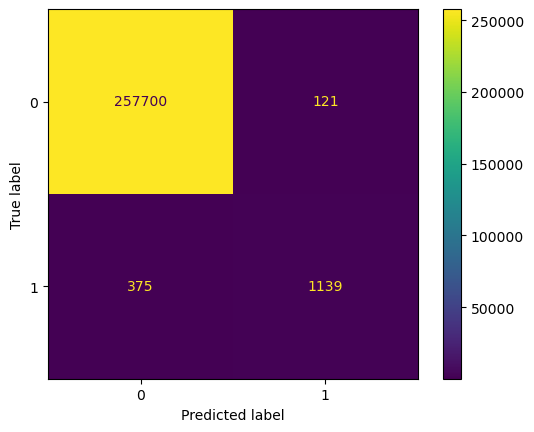

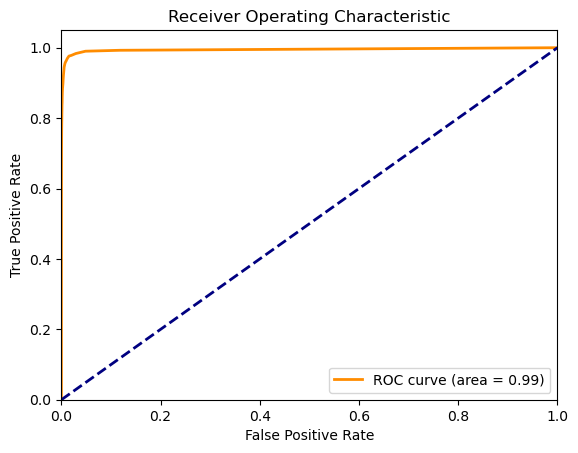

In [38]:
measure_metrics(y_test_unbalanced, y_pred_rf_smote_train, y_prob_rf_smote_train)

In [39]:
y_pred_rf_smote = rf_smote.predict(X_test_actual)
y_prob_rf_smote = rf_smote.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9972162189883736
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.66      0.58      0.62      2145

    accuracy                           1.00    555719
   macro avg       0.83      0.79      0.81    555719
weighted avg       1.00      1.00      1.00    555719

ROC AUC Score: 0.9776815481122403


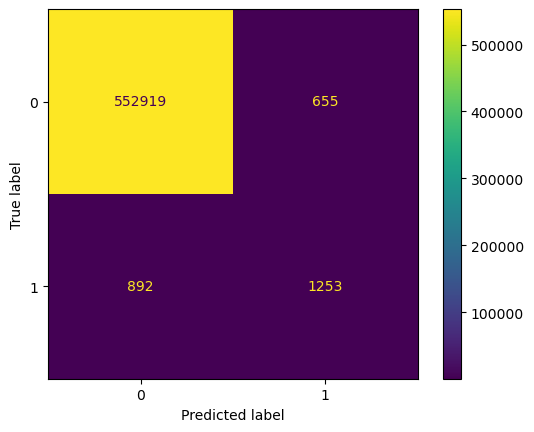

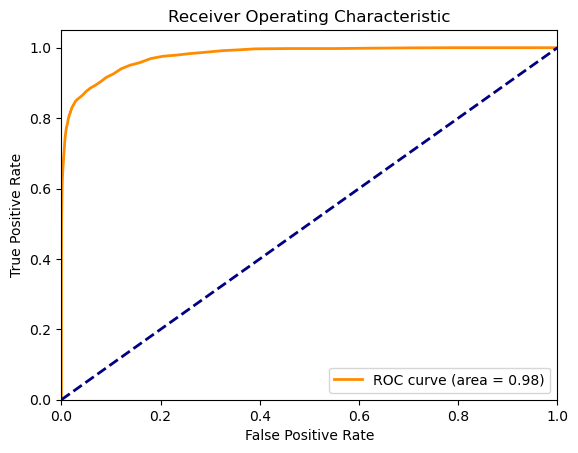

In [40]:
measure_metrics(y_test_actual, y_pred_rf_smote, y_prob_rf_smote)

#### Random Forest -

In [41]:
importances_rf = rf_smote.feature_importances_

# Select the top n features or based on a threshold
n_features = 22  # You can also use a threshold approach
indices = np.argsort(importances_rf)[::-1]
selected_features_rf = indices[:n_features]

In [42]:
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances_rf
})

In [43]:
feature_importance_rf.sort_values(by='Importance', ascending=True)

,Feature,Importance
31,job_category_Retail & Customer Service,0.000139
25,job_category_Hospitality & Tourism,0.000224
28,job_category_Other/Uncategorized,0.000289
33,job_category_Science & Technology,0.000303
34,job_category_Social Services & Community Work,0.000320
26,job_category_IT & Technology,0.000333
35,job_category_Transport & Logistics,0.000345
30,job_category_Public Service & Government,0.000413
32,job_category_Science & Research,0.000427
27,job_category_Law & Security,0.000445


In [44]:
from sklearn.model_selection import RandomizedSearchCV
# Simplified hyperparameter grid
random_search_rf = {
    'n_estimators': [100, 200, 300],  # Reduced range
    'max_features': ['sqrt', 'log2'],  # Fewer options
    'max_depth': [10, 50, 100, None],  # Fewer options
    'min_samples_split': [2, 5],  # Only two values
    'min_samples_leaf': [1, 2],  # Only two values
    'bootstrap': [True, False]  # Same options
}

In [45]:
cv_rf = RandomForestClassifier()
from sklearn.model_selection import cross_val_score, StratifiedKFold
skf_rf = StratifiedKFold(n_splits=2)

In [47]:
model_rf_tune = RandomizedSearchCV(
    estimator=cv_rf, 
    param_distributions=random_search_rf, 
    cv=skf_rf,  # Use StratifiedKFold for cross-validation
    verbose=10, 
    random_state=101, 
    scoring='f1'  # Optimize for recall
)

In [48]:
model_rf_tune.fit(X_train_smote, y_train_smote)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV 1/2; 1/10] START bootstrap=True, max_depth=100, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 1/2; 1/10] END bootstrap=True, max_depth=100, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.998 total time= 3.6min
[CV 2/2; 1/10] START bootstrap=True, max_depth=100, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 2/2; 1/10] END bootstrap=True, max_depth=100, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=1.000 total time= 3.7min
[CV 1/2; 2/10] START bootstrap=False, max_depth=100, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=200
[CV 1/2; 2/10] END bootstrap=False, max_depth=100, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=200;, score=0.998 total time= 9.1min
[CV 2/2; 2/10] START bootstrap=False, max_depth=100, max_features=log2

RandomizedSearchCV(cv=StratifiedKFold(n_splits=2, random_state=None, shuffle=False),
                   estimator=RandomForestClassifier(),
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 50, 100, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 200, 300]},
                   random_state=101, scoring='f1', verbose=10)

In [49]:
y_pred_rf_smote_test = model_rf_tune.predict(X_test_actual)
y_prob_rf_smote_test = model_rf_tune.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9979881918739507
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.91      0.53      0.67      2145

    accuracy                           1.00    555719
   macro avg       0.95      0.77      0.84    555719
weighted avg       1.00      1.00      1.00    555719

ROC AUC Score: 0.9702418102370051


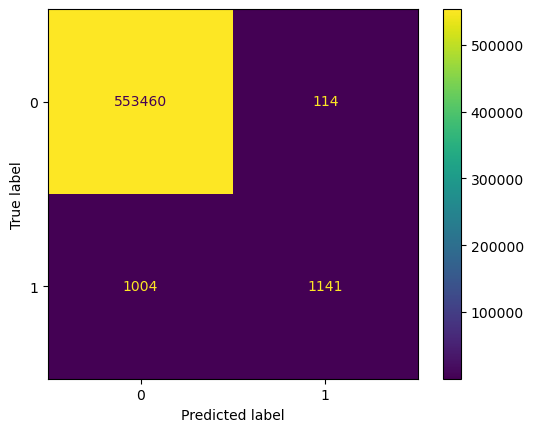

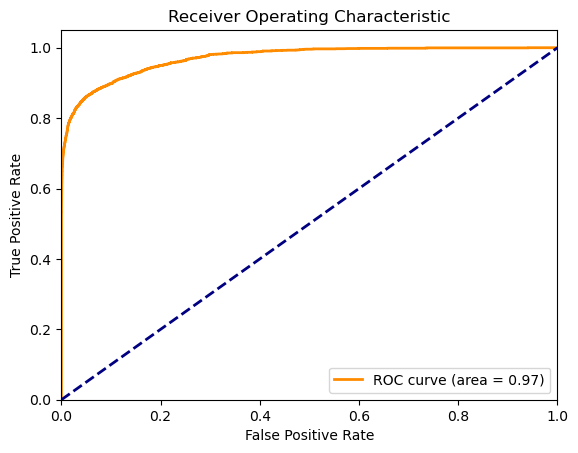

In [51]:
measure_metrics(y_test_actual, y_pred_rf_smote_test, y_prob_rf_smote_test)

In [52]:
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

In [53]:
scoring = {
    'precision': make_scorer(precision_score, average='binary'),
    'recall': make_scorer(recall_score, average='binary'),
    'f1': make_scorer(f1_score, average='binary')
}

In [55]:
model_rf_tune_all = RandomizedSearchCV(
    estimator=cv_rf, 
    param_distributions=random_search_rf, 
    cv=skf_rf,  # Use StratifiedKFold for cross-validation
    verbose=10, 
    random_state=101,      
    
    scoring=scoring, 
    refit='f1' # Optimize for recall
)

In [56]:
model_rf_tune_all.fit(X_train_smote, y_train_smote)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV 1/2; 1/10] START bootstrap=True, max_depth=100, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 1/2; 1/10] END bootstrap=True, max_depth=100, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; f1: (test=0.998) precision: (test=0.999) recall: (test=0.997) total time= 3.7min
[CV 2/2; 1/10] START bootstrap=True, max_depth=100, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 2/2; 1/10] END bootstrap=True, max_depth=100, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; f1: (test=1.000) precision: (test=0.999) recall: (test=1.000) total time= 3.7min
[CV 1/2; 2/10] START bootstrap=False, max_depth=100, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=200
[CV 1/2; 2/10] END bootstrap=False, max_depth=100, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=200; f1: 

RandomizedSearchCV(cv=StratifiedKFold(n_splits=2, random_state=None, shuffle=False),
                   estimator=RandomForestClassifier(),
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 50, 100, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 200, 300]},
                   random_state=101, refit='f1',
                   scoring={'f1': make_scorer(f1_score, response_method='predict', average=binary),
                            'precision': make_scorer(precision_score, response_method='predict', average=binary),
                            'recall': make_scorer(recall_score, response_method='predict', average=binary)},
                   verbose=10)

In [57]:
y_pred_rf_smote_train_all = model_rf_tune_all.predict(X_test_unbalanced)
y_prob_rf_smote_train_all = model_rf_tune_all.predict_proba(X_test_unbalanced)[:, 1]

Accuracy: 0.9980449997107987
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257821
           1       0.94      0.71      0.81      1514

    accuracy                           1.00    259335
   macro avg       0.97      0.86      0.90    259335
weighted avg       1.00      1.00      1.00    259335

ROC AUC Score: 0.9958207361638269


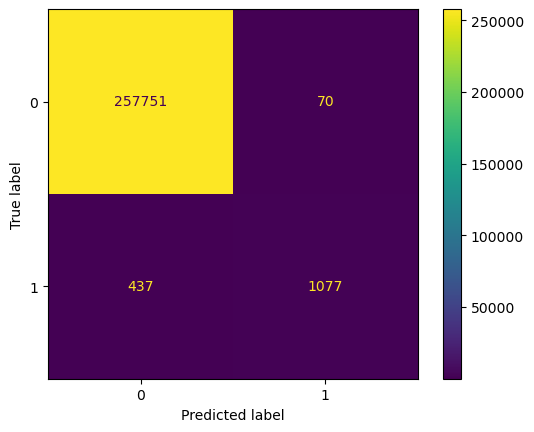

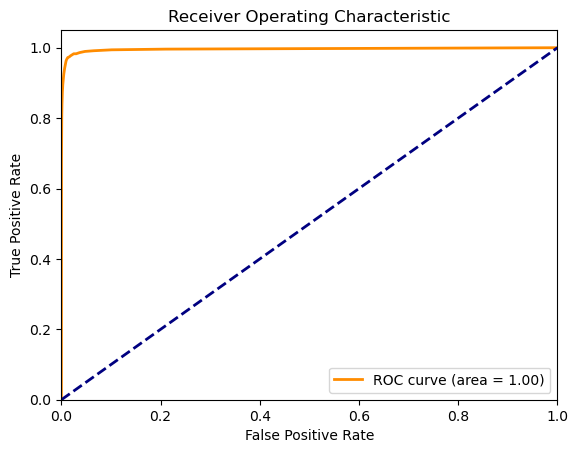

In [59]:
measure_metrics(y_test_unbalanced, y_pred_rf_smote_train_all, y_prob_rf_smote_train_all)

In [60]:
y_pred_rf_smote_test_all = model_rf_tune_all.predict(X_test_actual)
y_prob_rf_smote_test_all = model_rf_tune_all.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9978748252264183
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.87      0.53      0.66      2145

    accuracy                           1.00    555719
   macro avg       0.93      0.76      0.83    555719
weighted avg       1.00      1.00      1.00    555719

ROC AUC Score: 0.9624838419127891


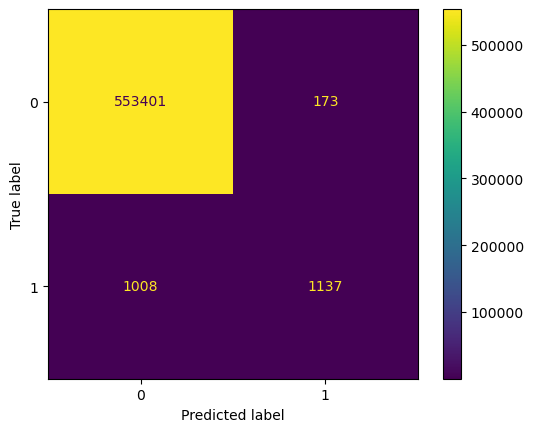

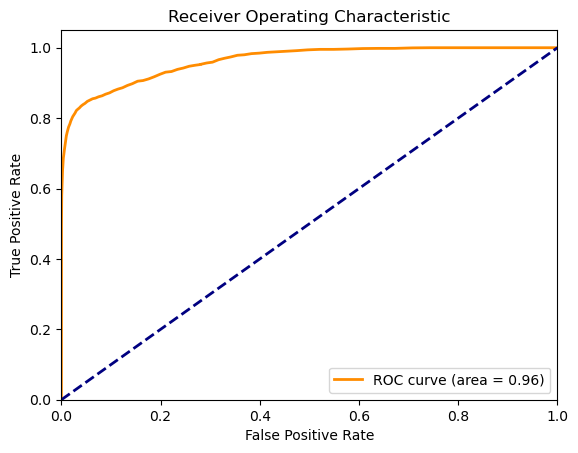

In [61]:
measure_metrics(y_test_actual, y_pred_rf_smote_test_all, y_prob_rf_smote_test_all)